In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from torchvision import models

from PIL import Image
from matplotlib import pyplot as plt

## Классная работа

In [2]:
vgg_weights = models.VGG16_Weights.DEFAULT
vgg_model = models.vgg16(weights=vgg_weights)

In [3]:
vgg_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [4]:
cats = vgg_weights.meta['categories']
transforms_1 = vgg_weights.transforms()

In [6]:
img = Image.open("data/img_2.jpeg").convert("RGB")
img_net = transforms_1(img).unsqueeze(0)

In [9]:
vgg_model.eval()
p = vgg_model(img_net).squeeze() # (1000)

In [ ]:
res = p.softmax(dim=0).sort(descending=True)
for s, i in zip(res[0][:5], res[1][:5]):
    print(f"{cats[i]}: {s:.4f}")

sports car: 0.8374
racer: 0.1341
convertible: 0.0085
passenger car: 0.0074
car wheel: 0.0060


In [15]:
res

torch.return_types.sort(
values=tensor([8.3740e-01, 1.3413e-01, 8.4641e-03, 7.3509e-03, 5.9593e-03, 2.3368e-03,
        2.2321e-03, 7.1369e-04, 2.7980e-04, 1.9795e-04, 1.7732e-04, 1.4233e-04,
        1.2483e-04, 6.8876e-05, 5.8488e-05, 4.7467e-05, 4.1691e-05, 3.4043e-05,
        3.3280e-05, 2.8961e-05, 2.1491e-05, 1.6315e-05, 1.0978e-05, 8.5310e-06,
        8.2611e-06, 6.9389e-06, 4.8224e-06, 4.6278e-06, 4.2235e-06, 3.9542e-06,
        3.8686e-06, 2.8291e-06, 2.7437e-06, 2.2567e-06, 2.2494e-06, 2.1092e-06,
        1.9098e-06, 1.9008e-06, 1.8193e-06, 1.8034e-06, 1.7153e-06, 1.5472e-06,
        1.3124e-06, 1.1824e-06, 1.1684e-06, 1.0758e-06, 1.0750e-06, 1.0415e-06,
        1.0259e-06, 1.0212e-06, 1.0132e-06, 1.0006e-06, 9.0282e-07, 8.9414e-07,
        8.3723e-07, 8.1768e-07, 7.0565e-07, 6.9747e-07, 6.9302e-07, 6.6808e-07,
        6.5204e-07, 6.4717e-07, 6.2790e-07, 6.2458e-07, 6.1818e-07, 5.6608e-07,
        5.1661e-07, 5.1420e-07, 5.1019e-07, 4.9914e-07, 4.9168e-07, 4.8557e-07,
        

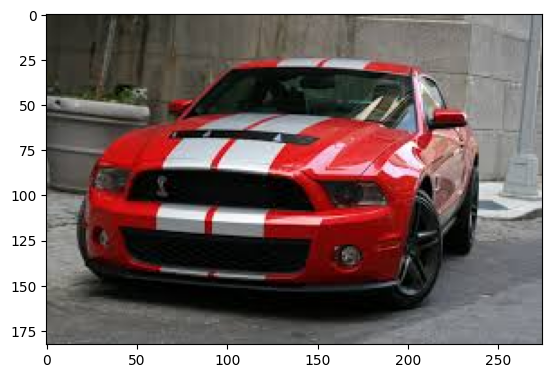

In [14]:
plt.imshow(img);

## Домашняя работа

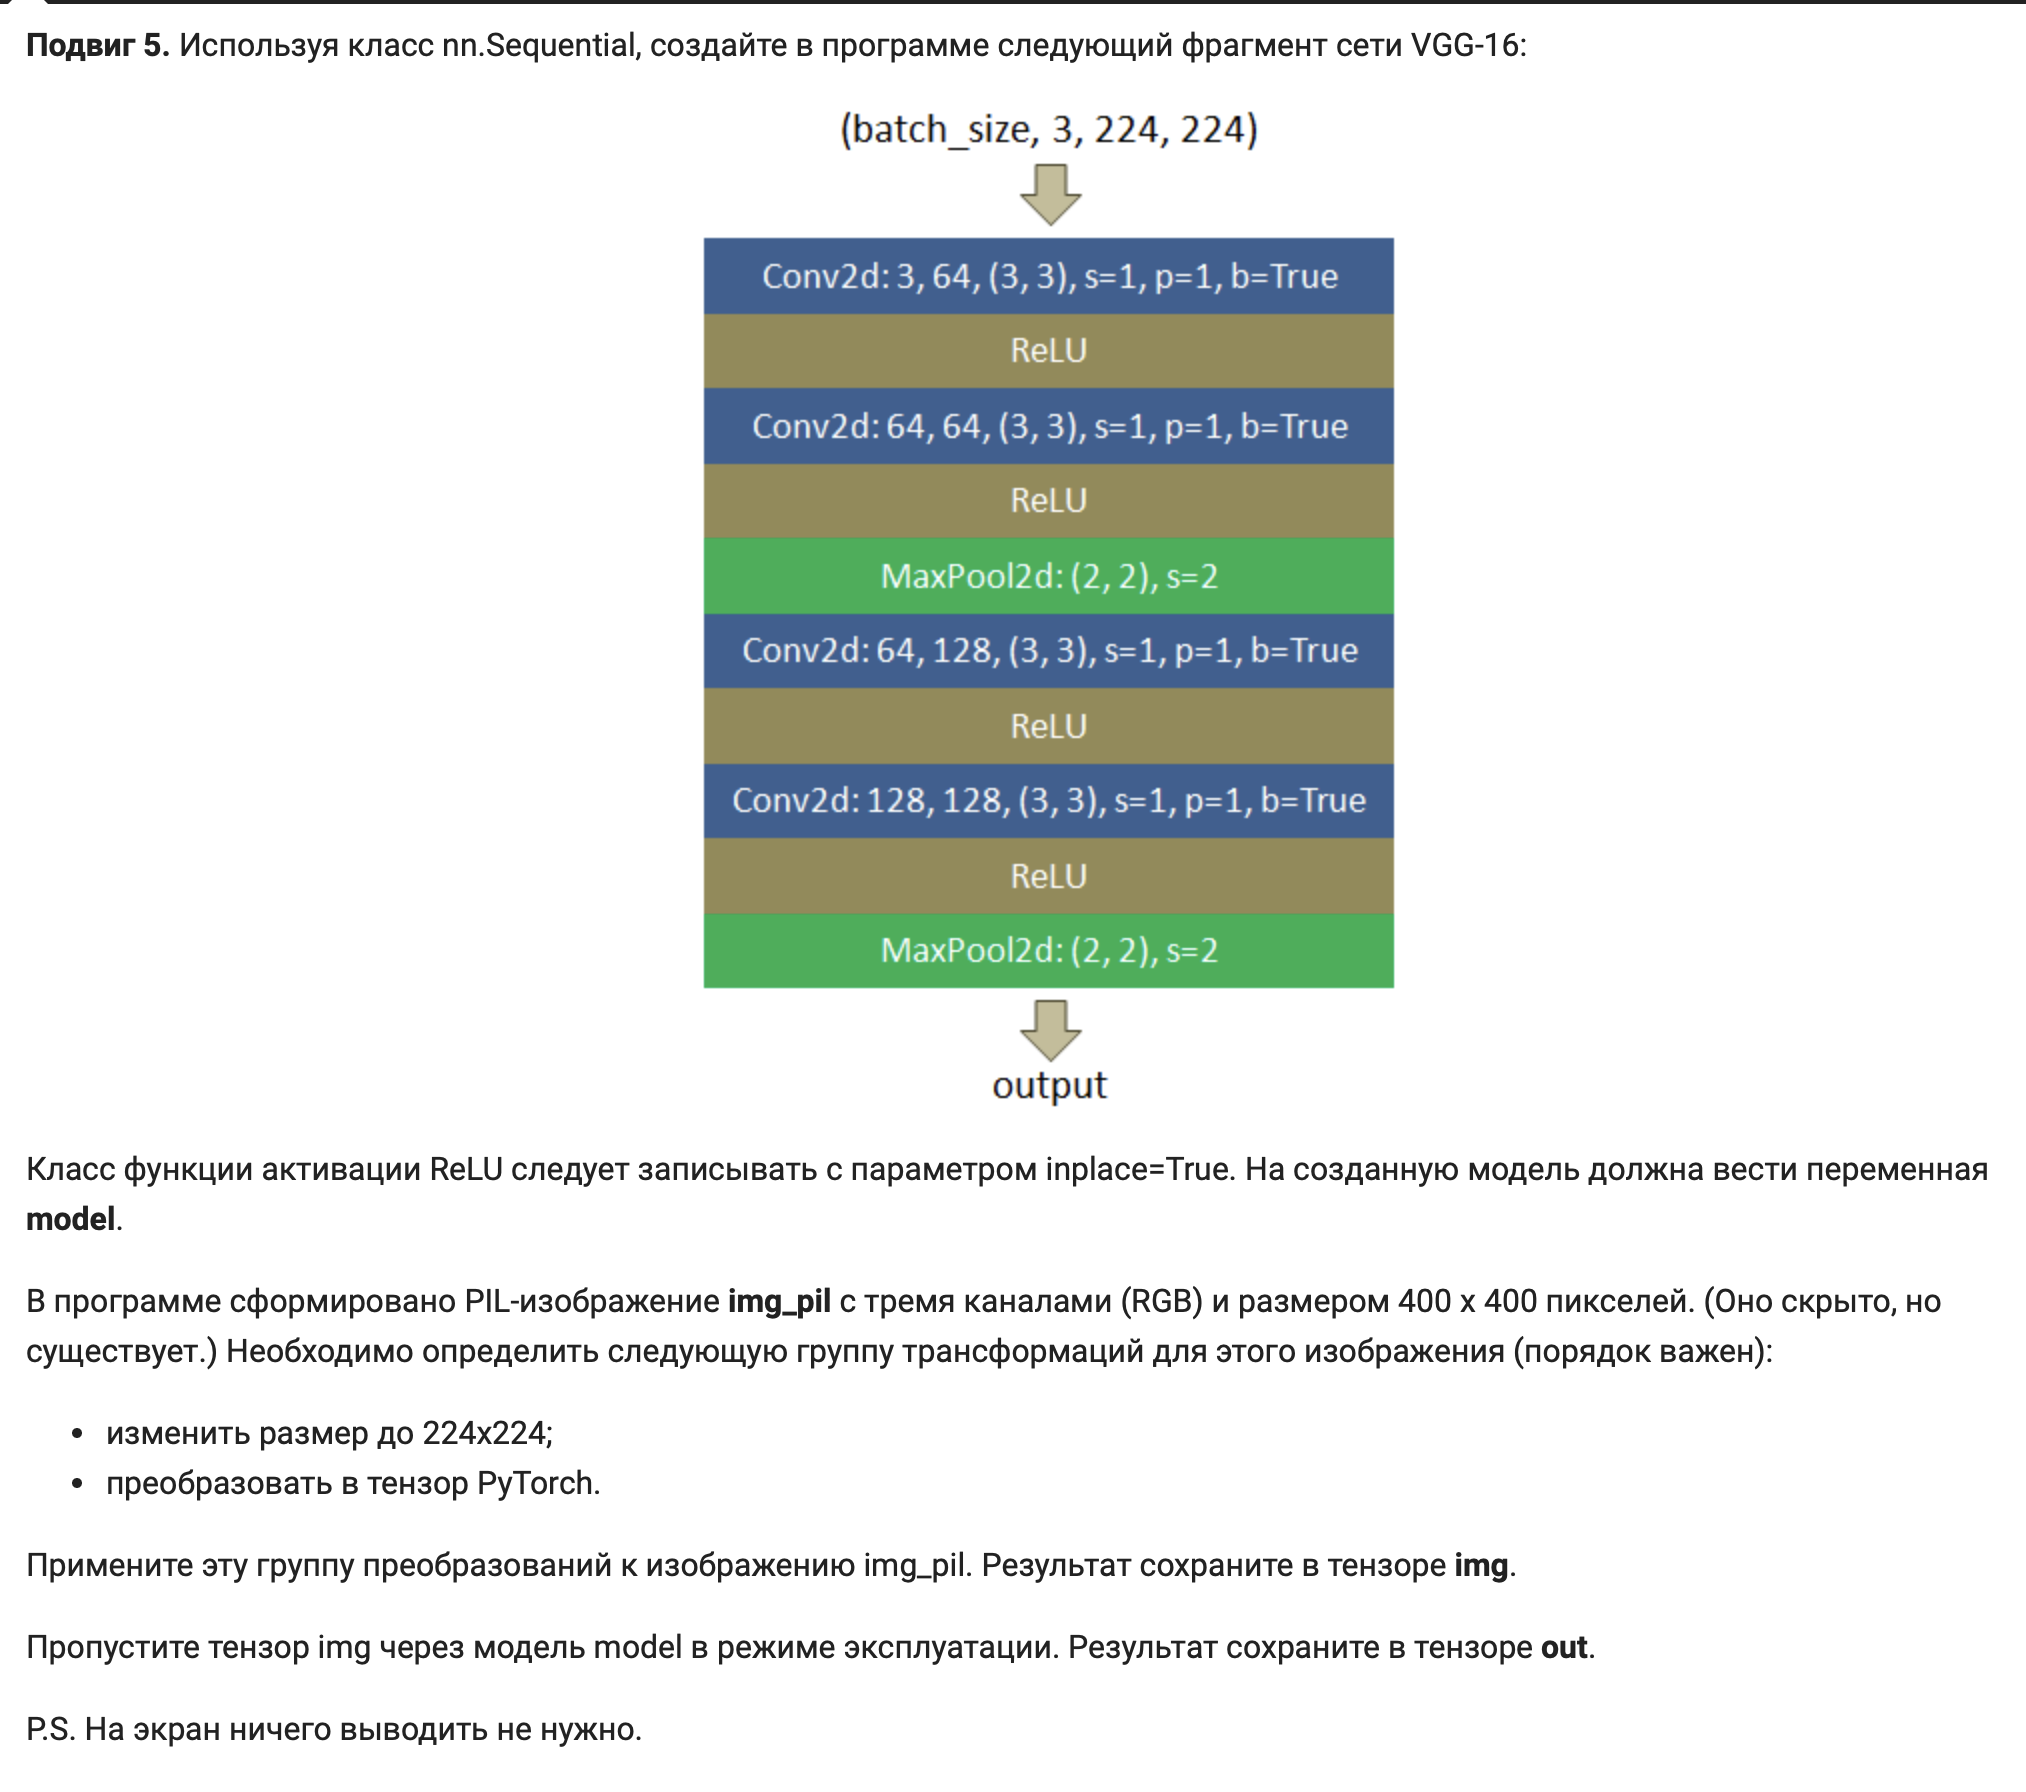

In [ ]:
import torch
import torchvision.transforms as tfs
import torch.nn as nn

# здесь продолжайте программу
model = nn.Sequential(
    nn.Conv2d(3, 64, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

transf = tfs.Compose([tfs.Resize((224, 224)), tfs.ToTensor()])
img = transf(img_pil)

model.eval()
out = model(img.unsqueeze(0))

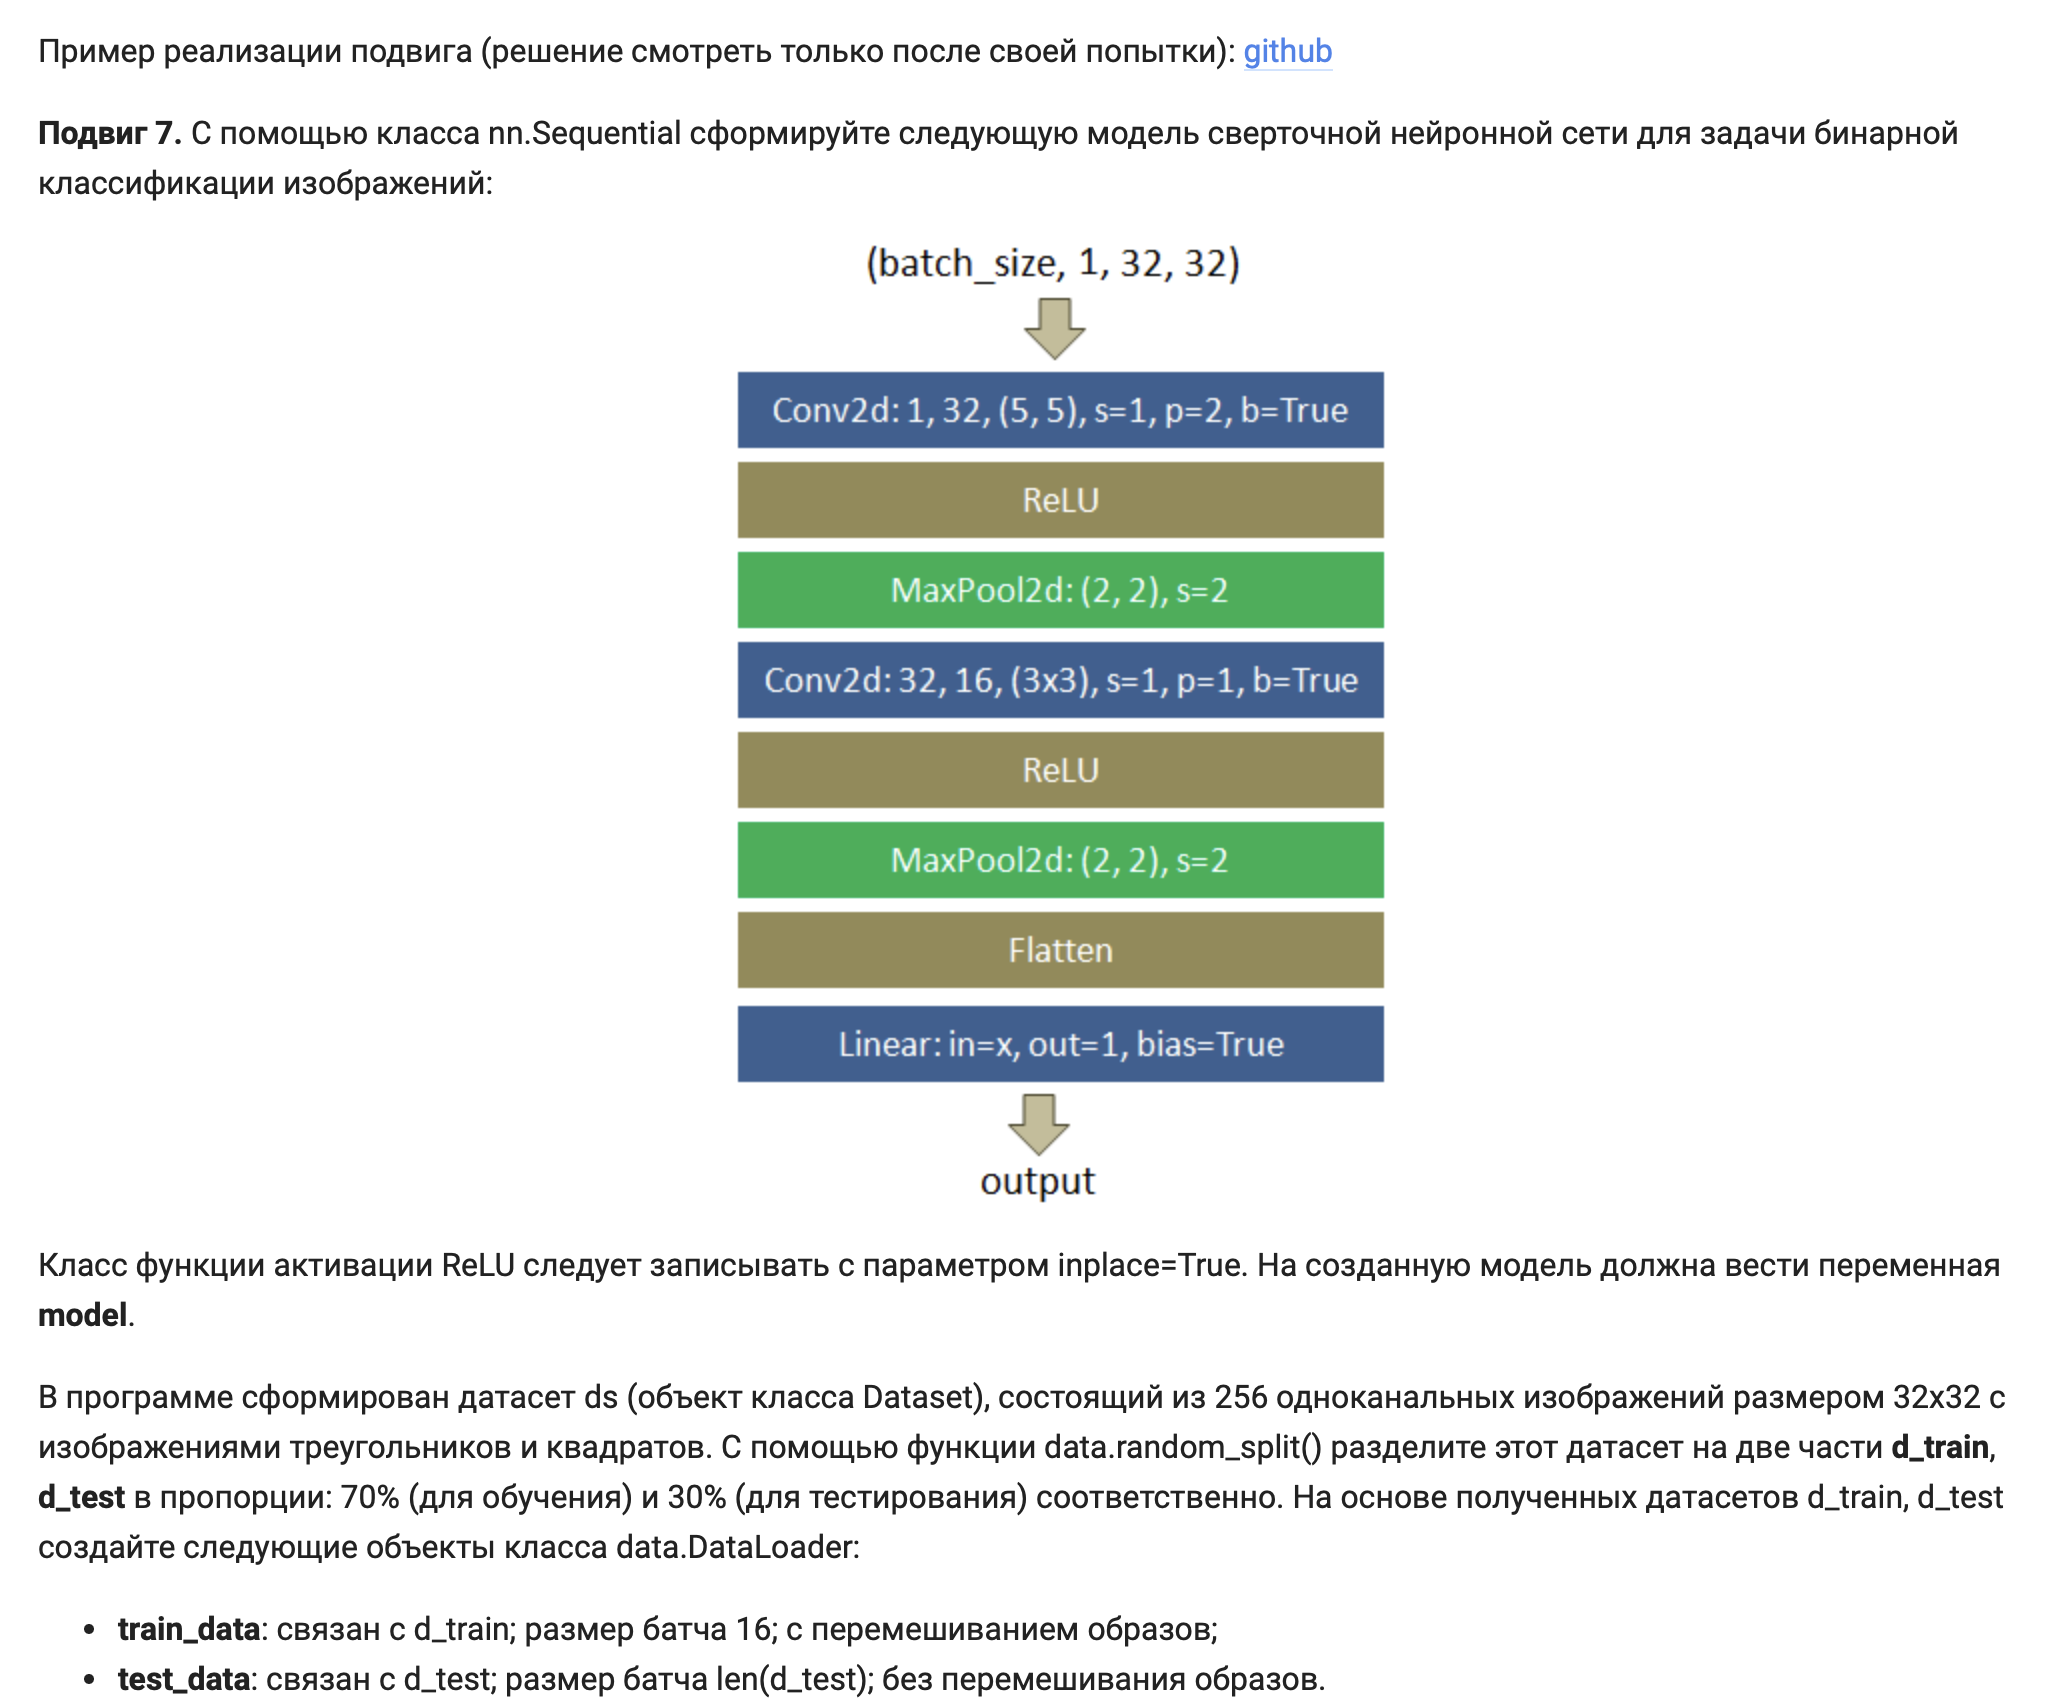
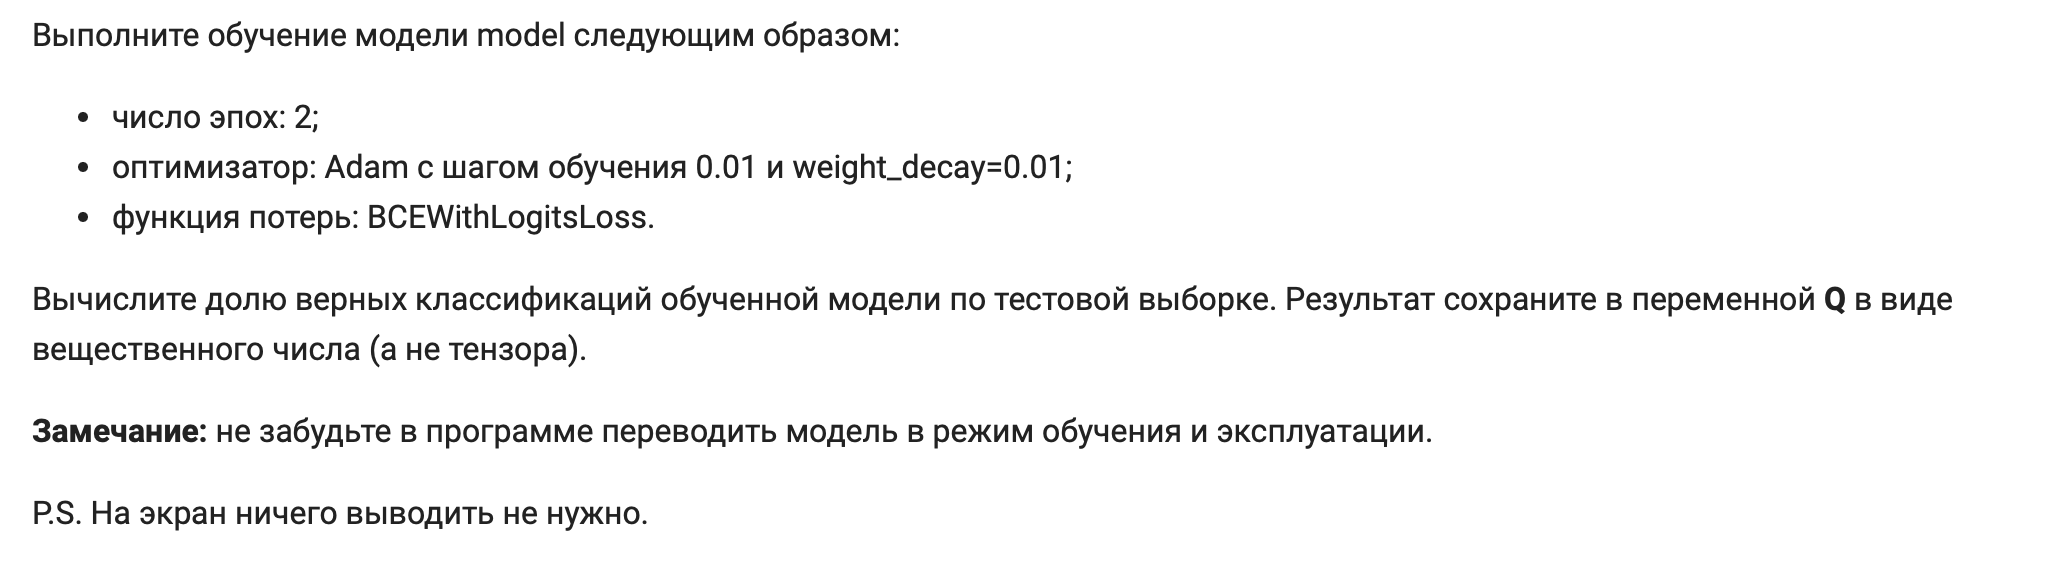

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 5, padding=2),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 16, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(8*8*16, 1)
)

#ds = data.TensorDataset(torch.ones(32))

d_train, d_test = data.random_split(ds, [0.7, 0.3])
data_train = data.DataLoader(d_train, batch_size=16, shuffle=True)
data_test = data.DataLoader(d_test, batch_size=len(d_test), shuffle=False)

epochs = 2
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)
loss_func = nn.BCEWithLogitsLoss()

model.train()
for _e in range(epochs):
    for x_train, y_train in data_train:
        pred = model(x_train)
        loss = loss_func(pred.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()
for x_test, y_test in data_test:
    with torch.no_grad():
        pred = model(x_test)
        Q = loss_func(pred.squeeze(), y_test).item()